In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('final_data.csv')

In [4]:
df.head()

,Age,Gender,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount,...,Occupation_Unemployed,Location_Suburban,Location_Urban,Customer Feedback_Good,Customer Feedback_Poor,Exercise Frequency_Monthly,Exercise Frequency_Rarely,Exercise Frequency_Weekly,Property Type_Condo,Property Type_House
0,1.401064,0,0.249045,-1.415125,-0.187967,0.002711,0.261175,-1.542179,0.771816,927.0,...,0,0,0,0,1,0,1,0,1,0
1,1.105844,0,-0.423218,-0.707191,0.319821,-0.997564,0.087671,-0.950250,-0.002958,828.0,...,0,0,1,0,0,1,0,0,1,0
2,-0.075033,1,-0.324269,1.416611,0.212165,0.002711,0.781689,1.392274,0.771816,975.0,...,1,0,0,0,1,0,1,0,0,1
3,-0.001228,0,-0.113265,0.000743,-0.965442,-0.997564,0.261175,-0.824308,1.546591,207.0,...,0,1,0,1,0,0,1,0,0,1
4,-1.624935,1,-0.981638,-1.415125,0.376007,-0.997564,1.649212,-0.799120,-1.552507,1.0,...,0,0,1,0,1,0,1,0,0,1


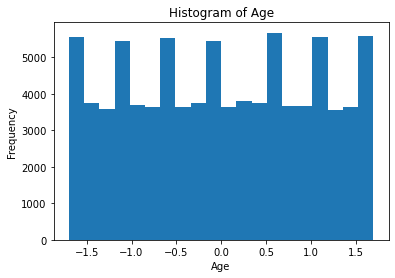

In [5]:
plt.hist(df['Age'], bins=20)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Histogram of Age')
plt.show()

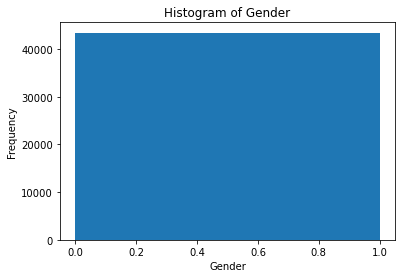

In [6]:
plt.hist(df['Gender'], bins=2)
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.title('Histogram of Gender')
plt.show()

In [7]:
cols = df.columns

In [8]:
cols = list(cols)
cols

['Age',
 'Gender',
 'Annual Income',
 'Number of Dependents',
 'Health Score',
 'Previous Claims',
 'Vehicle Age',
 'Credit Score',
 'Insurance Duration',
 'Premium Amount',
 'Smoking Status',
 'Policy Type encoded',
 'Marital Status_Married',
 'Marital Status_Single',
 'Education Level_High School',
 "Education Level_Master's",
 'Education Level_PhD',
 'Occupation_Self-Employed',
 'Occupation_Unemployed',
 'Location_Suburban',
 'Location_Urban',
 'Customer Feedback_Good',
 'Customer Feedback_Poor',
 'Exercise Frequency_Monthly',
 'Exercise Frequency_Rarely',
 'Exercise Frequency_Weekly',
 'Property Type_Condo',
 'Property Type_House']

In [9]:
del cols[11:]

In [10]:
cols

['Age',
 'Gender',
 'Annual Income',
 'Number of Dependents',
 'Health Score',
 'Previous Claims',
 'Vehicle Age',
 'Credit Score',
 'Insurance Duration',
 'Premium Amount',
 'Smoking Status']

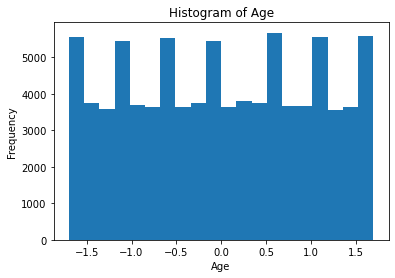

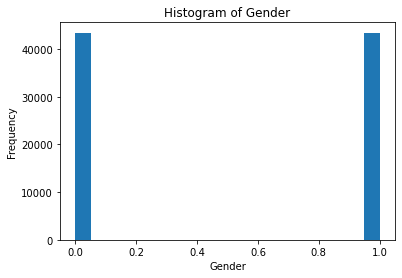

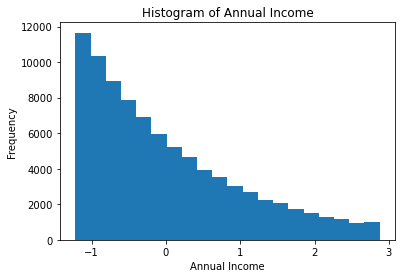

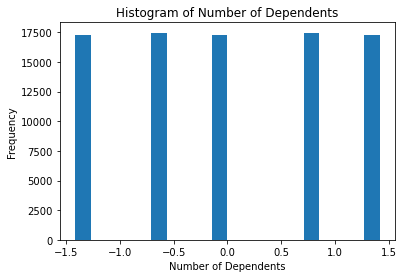

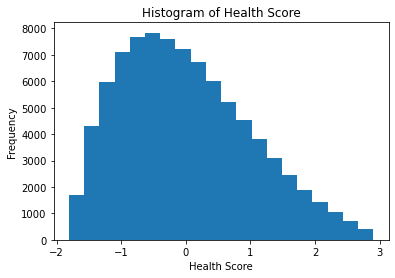

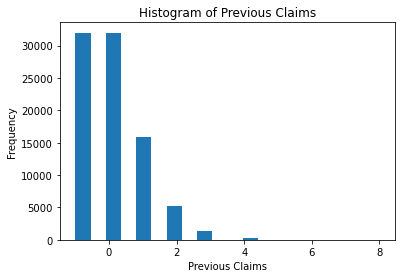

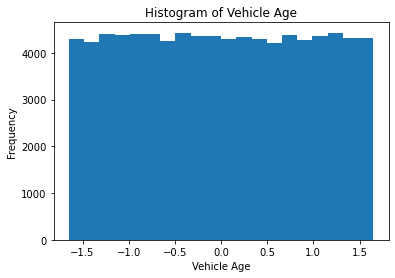

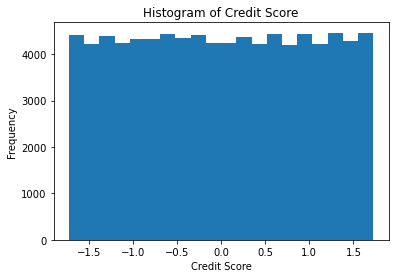

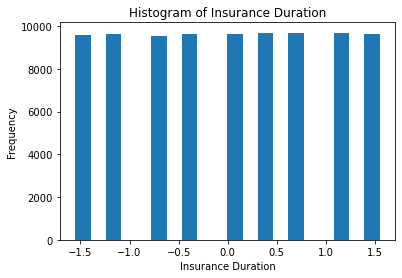

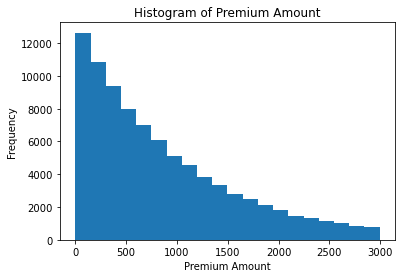

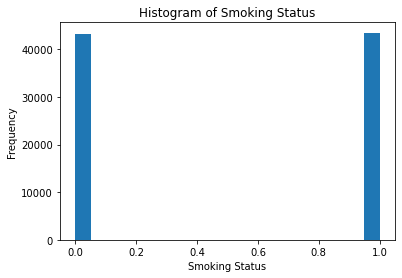

In [11]:
for i in cols:
    plt.hist(df[str(i)], bins=20)
    plt.xlabel(str(i))
    plt.ylabel('Frequency')
    plt.title('Histogram of '+ str(i))
    plt.show()

### The Inverse Transform Method
- The most common and theoretically sound way is to use the inverse CDF (quantile function) of the normal distribution.

Here’s why:

If 𝑋 ∼ 𝑈 (0 , 1) X∼U(0,1) (uniform between 0 and 1), 
then, 𝑌 = 𝐹^-1(𝑋)
Y=F^-1(X) will be distributed according to the distribution with CDF F.

For a normal distribution, F^-1 is the inverse normal CDF, also called the probit function.


In [12]:
from scipy.stats import norm

In [13]:
def uniTOnorm(data):
    X_scaled = (data - data.min()) / (data.max() - data.min())
    X_scaled = np.clip(X_scaled, 1e-10, 1 - 1e-10)
    normal = norm.ppf(X_scaled)
    
    return normal

In [14]:
# Credit Score, Age, Vehicle Age
uniform_cols = ['Credit Score', 'Age', 'Vehicle Age']

# Apply the function to a specific list of columns
df[uniform_cols] = df[uniform_cols].apply(uniTOnorm)

### Skewed Data

-it seems that Premium Amount is right-skewed (positively skewed)

#### Good transformation for left skew
General rule:
- For right skew: log(x), sqrt(x), or 1/x work well.
- For left skew: First reflect the data, then apply a right-skew fix.

#### The reflection trick
Steps:
- Apply a right-skew fix:
Try log(), sqrt(), or Box-Cox.


In [15]:
from scipy.stats import boxcox

In [16]:
df[df['Premium Amount'] < 0].value_counts()

Series([], dtype: int64)

In [17]:
# # 1. Reflect
# premium_reflected = df['Premium Amount'].max() + 1 - df['Premium Amount']

# 2a. Log transform
premium_transformed = np.log(df['Premium Amount'])

# OR 2b. Box-Cox (automatically finds best power)
# Box-Cox needs positive data, so reflection works well
# premium_bc, lmbda = boxcox(df['Premium Amount'])

c:\Users\ROHIT\anaconda3\lib\site-packages\pandas\core\arraylike.py:397: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


ValueError: supplied range of [-inf, 8.00469951054955] is not finite

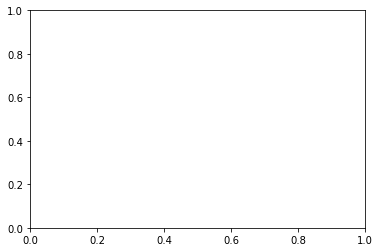

In [ ]:
# plt.hist(premium_transformed, bins=20)
# plt.xlabel('premium_transformed')
# plt.ylabel('Frequency')
# plt.title('Histogram of premium_transformed')
# plt.show()


# # plt.hist(premium_bc, bins=20)
# # plt.xlabel('premium_bc')
# # plt.ylabel('Frequency')
# # plt.title('Histogram of premium_bc')
# # plt.show()